In [ ]:
import MDAnalysis as MDA
from MDAnalysis.analysis import rms
from MDAnalysis.analysis.dihedrals import Dihedral

import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from utils import get_chemical_shifts, ATOM_TYPES

def calc_RMSD(u, ref_u, atom_select="name CA", step=1):
    R = rms.RMSD(u, ref_u, select=atom_select,
                 center=True, superposition=True
                )
    R.run(step=step)
    rmsd = R.results.rmsd.T 
    return rmsd[2]

def calc_helicity(u, CA_sel='name CA', step=1):
    h_region = (np.rad2deg(0.25),np.rad2deg(1.3))
    CA_select = u.select_atoms(CA_sel)
    N = len(CA_select)
    diheds = Dihedral([CA_select[i:i+4] for i in range(N-3)]).run(step=step).results.angles

    pseudo_helicity = np.full((diheds.shape[0],N), False)
    for i in range(N-3):
        is_in_basin = np.where((diheds[:,i]>h_region[0])&(diheds[:,i]<h_region[1]), True, False)
        pseudo_helicity[:,i+1] = pseudo_helicity[:,i+1] | is_in_basin
        pseudo_helicity[:,i+2] = pseudo_helicity[:,i+2] | is_in_basin
    helicity = np.full((diheds.shape[0],N), False)
    for i in range(1,N-1):
        helicity[:,i] = np.all(pseudo_helicity[:,i-1:i+1], axis=1)
    return helicity


# Plotting CS RMSD

Get "experimental" CS (or whatever is in the input CS file), random coil CS, and (secondary) CS predicted from a simulation

In [74]:
exp_CS, RC_CS, pred_CS = get_chemical_shifts("../TestSystems/FCP1/ForceFields/CALVADOS/system/helical_modelled_CA.pdb",
                                             "../TestSystems/FCP1/ForceFields/CALVADOS/simulations/example_simulation/rep0/output.xtc",
                                             "../TestSystems/FCP1/NMRData/PROSECCO_helical_CS.txt",
                                             mapping='CA')

/home/mcul245/anaconda3/envs/BuildOpenMMNapShift/lib/python3.11/site-packages/torch/serialization.py:1493: UserWarning: 'torch.load' received a zip file that looks like a TorchScript archive dispatching to 'torch.jit.load' (call 'torch.jit.load' directly to silence this warning)
  warnings.warn(
/home/mcul245/anaconda3/envs/BuildOpenMMNapShift/lib/python3.11/site-packages/pycamcoil/camcoil_engine.py:108: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  self.df[f_name] = read_csv(f_path, header=None, delim_whitespace=" ",
/home/mcul245/anaconda3/envs/BuildOpenMMNapShift/lib/python3.11/site-packages/pycamcoil/camcoil_engine.py:108: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  self.df[f_name] = read_csv(f_path, header=None, delim_whitespace=" ",
/home/mcul245/anaconda3/envs/BuildOpenMMNapShift/lib/

Compute CS root mean square deviation from experiments and plot this time-trace for each atom type

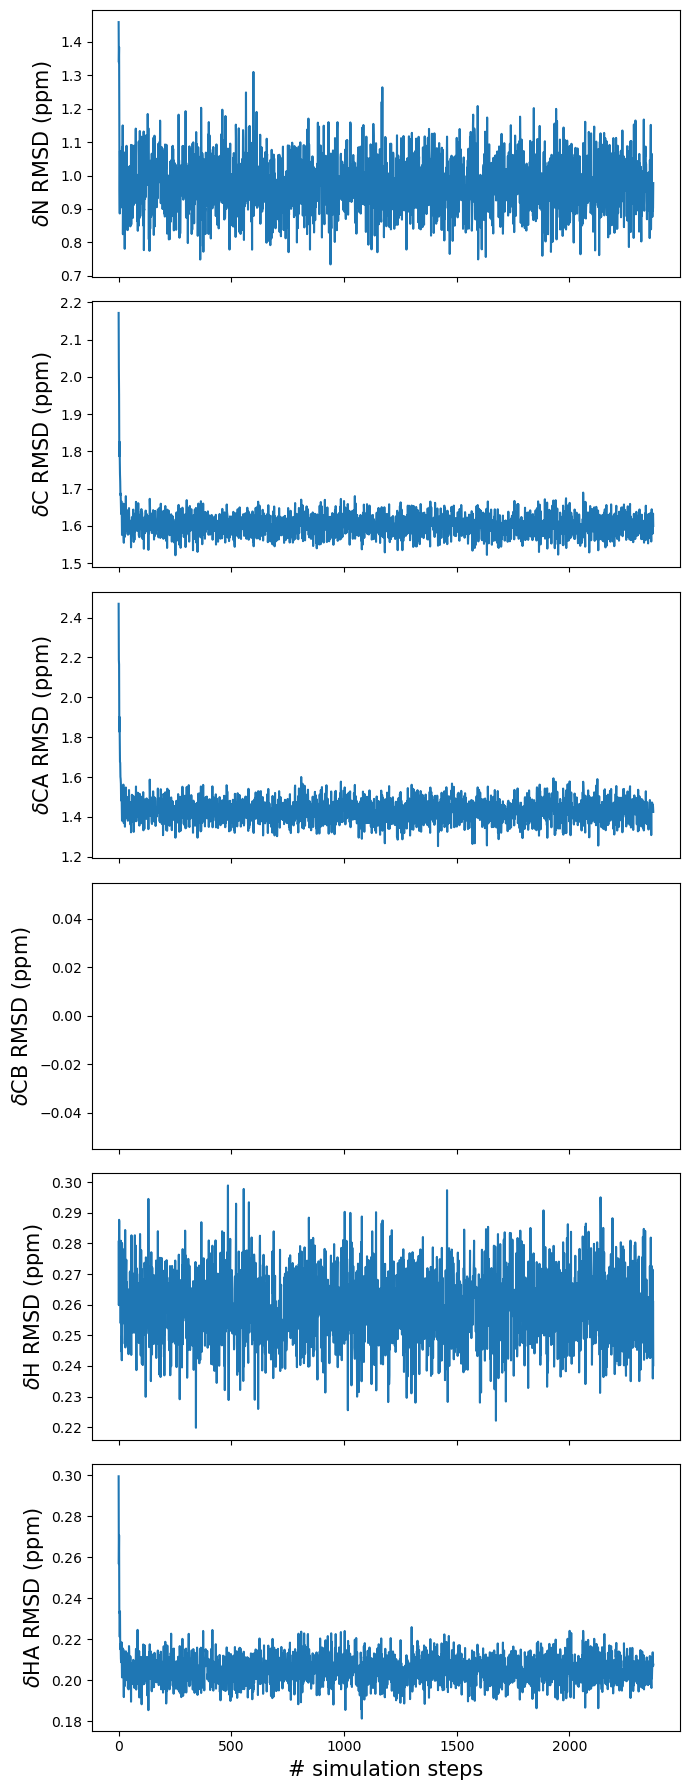

In [75]:
fig, axs = plt.subplots(6,1,figsize=(7,3*6), sharex=True)
for a, atom in enumerate(ATOM_TYPES):
    axs[a].set_ylabel(f"$\delta${atom} RMSD (ppm)", fontsize=15)
    axs[a].plot(np.sqrt((np.square((exp_CS[a]-RC_CS[a])-pred_CS[a])).mean(axis=1)))
axs[-1].set_xlabel(f"# simulation steps", fontsize=15)
fig.tight_layout()

Plot distributions of CS RMSD for each atom type (trimming 1000 steps of equilibration time)

/tmp/ipykernel_2919622/4112296274.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs.set_xticklabels([f"$\delta${a}" for a in ATOM_TYPES], fontsize=15)


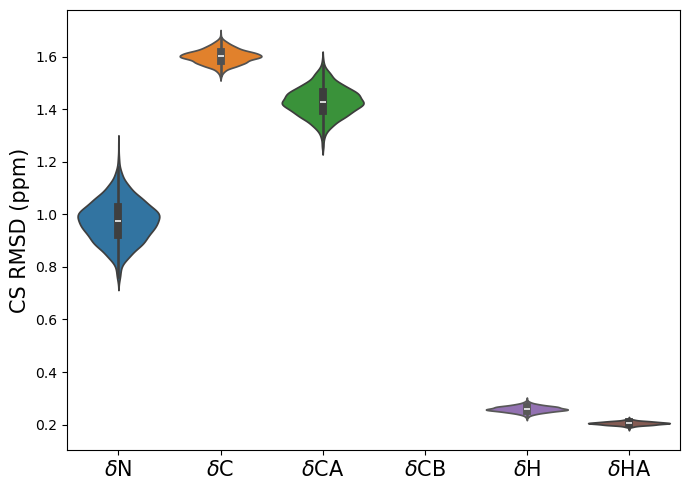

In [78]:
fig, axs = plt.subplots(1,1,figsize=(7,5), sharex=True)
for a, atom in enumerate(ATOM_TYPES):
    sns.violinplot(x=a, y=np.sqrt((np.square((exp_CS[a]-RC_CS[a])-pred_CS[a])).mean(axis=1))[1000:], ax=axs)
axs.set_ylabel(f"CS RMSD (ppm)", fontsize=15)
axs.set_xticklabels([f"$\delta${a}" for a in ATOM_TYPES], fontsize=15)
fig.tight_layout()

# CA RMSD

Calculate the RMSD from the reference/starting structure over CA (or BB) coordinates

In [71]:
ref_u = MDA.Universe("../TestSystems/FCP1/ForceFields/CALVADOS/system/helical_modelled_CA.pdb")
u = MDA.Universe("../TestSystems/FCP1/ForceFields/CALVADOS/system/helical_modelled_CA.pdb", "../TestSystems/FCP1/ForceFields/CALVADOS/simulations/example_simulation/rep0/output.xtc")
rmsd = calc_RMSD(u,ref_u, atom_select="name CA") # make sure to set atom_select="name BB" if you are using Martini3

/home/mcul245/anaconda3/envs/BuildOpenMMNapShift/lib/python3.11/site-packages/MDAnalysis/coordinates/PDB.py:479: UserWarning: 1 A^3 CRYST1 record, this is usually a placeholder. Unit cell dimensions will be set to None.
  warnings.warn(


Plot a timetrace of CA/BB RMSD

Text(0.5, 0, '# simulation steps')

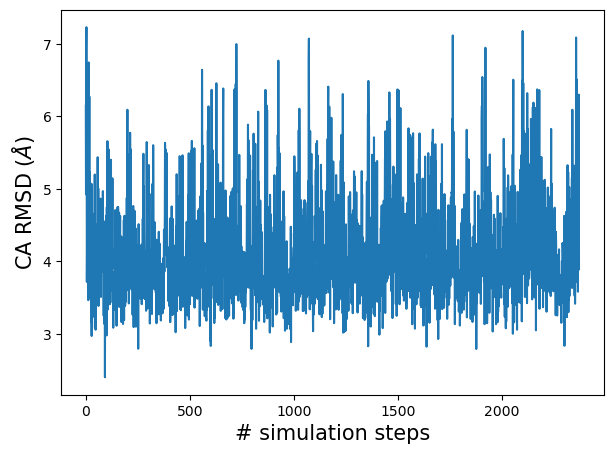

In [80]:
fig,axs = plt.subplots(1,1,figsize=(7,5))
axs.plot(rmsd)
axs.set_ylabel(r"CA RMSD ($\AA$)", fontsize=15)
axs.set_xlabel(f"# simulation steps", fontsize=15)

Plot this as a distribution (trimming 1000 steps of equilibration time)

Text(0, 0.5, 'Density')

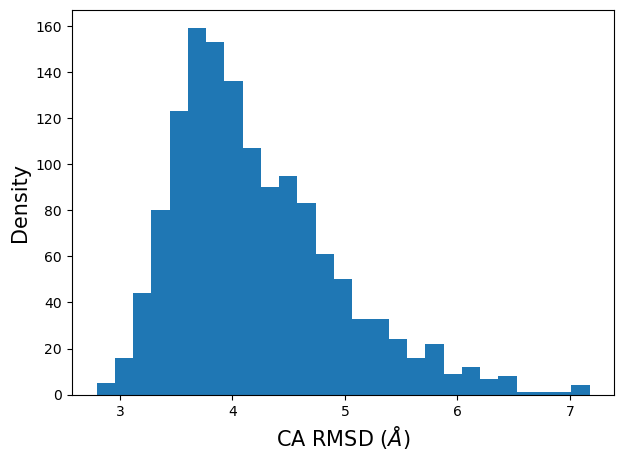

In [81]:
fig,axs = plt.subplots(1,1,figsize=(7,5))
axs.hist(rmsd[1000:], bins='fd')
axs.set_xlabel(r"CA RMSD ($\AA$)", fontsize=15)
axs.set_ylabel(f"Density", fontsize=15)

# Fractional helicity

Compute a dihedral-based measure of fractional helicity for each residue over the trajectory (described here: https://pubs.acs.org/doi/10.1021/acs.jcim.2c00450)

In [83]:
h = calc_helicity(MDA.Universe("../TestSystems/FCP1/ForceFields/CALVADOS/system/helical_modelled_CA.pdb", "../TestSystems/FCP1/ForceFields/CALVADOS/simulations/example_simulation/rep0/output.xtc"))

Plot a timetrace of average (over the protein chain) fractional helicity

Text(0.5, 0, '# simulation steps')

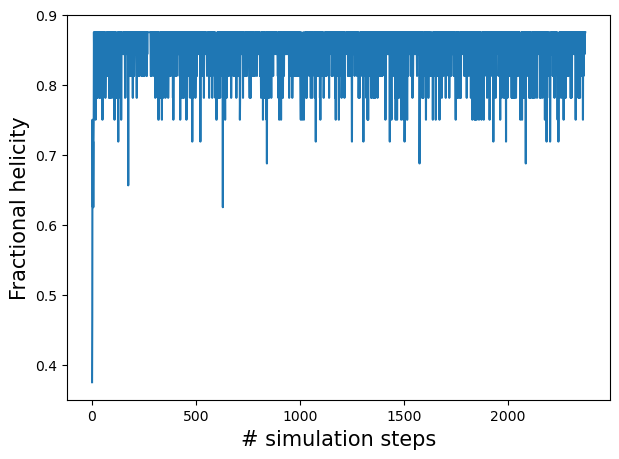

In [69]:
fig,axs = plt.subplots(1,1,figsize=(7,5))
axs.plot(h.mean(axis=1))
axs.set_ylabel(r"Fractional helicity", fontsize=15)
axs.set_xlabel(f"# simulation steps", fontsize=15)

Plot the per-residue average fractional helicity (trimming 1000 steps of equilibration time)

Text(0.5, 0, 'Residue #')

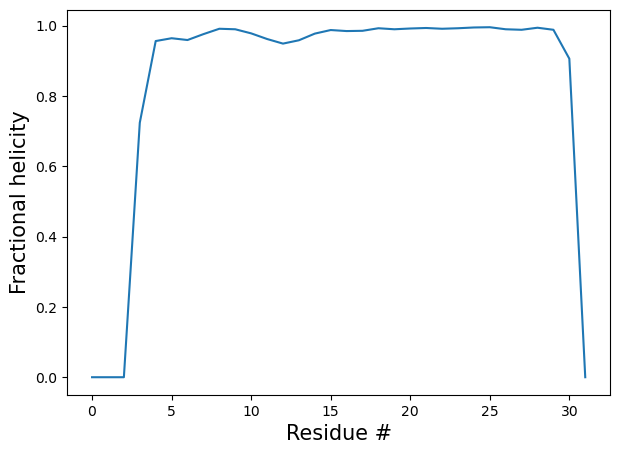

In [84]:
fig,axs = plt.subplots(1,1,figsize=(7,5))
axs.plot(h[1000:,:].mean(axis=0))
axs.set_ylabel(r"Fractional helicity", fontsize=15)
axs.set_xlabel(f"Residue #", fontsize=15)